# Physics Informed Neural Network for 2D Diffusion Equation

### 2D Diffusion equation, with a forcing term:

$$\frac{\partial u}{\partial t} =\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}-e^{-t}(1-2\pi^2)sin(\pi x)sin(\pi y)$$

$$x,y\in[-1,1]$$
$$t\in[0,1]$$

### Initial Condition:

$$u(x,y,0)=sin(\pi x)sin(\pi y)$$

### Boundary Conditions:

$$u(-1,y,t)=0$$
$$u(1,y,t)=0$$
$$u(x,-1,t)=0$$
$$u(x,1,y,t)=0$$

### Exact solution:

$$u(x,y,t)=e^{-t}sin(\pi x)sin(\pi y)$$

### Partial Differential Equation:

Rearranging the 2D Diffusion partial differential equation:

$$\left(\frac{\partial u}{\partial t} -\frac{\partial^2 u}{\partial x^2} -\frac{\partial^2 u}{\partial y^2}\right)+e^{-t}(1-2\pi^2)sin(\pi x)sin(\pi y)=0$$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import functools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# 2D Diffusion exact solution
def exact_solution(x, y, t):
    return torch.exp(-t) * torch.sin(torch.pi*x) * torch.sin(torch.pi*y)

In [3]:
class Diffusion2D_MLP(nn.Module):
    def __init__(self, hidden_dim=64, hidden_layers=3):
        super().__init__()

        # Build the MLP architecture
        layers = [nn.Linear(3, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        # Initialize linear layers with Xavier initialization
        for i in range(0, len(layers)-1, 2):
            nn.init.xavier_normal_(self.net[i].weight.data, gain=1.0)
            nn.init.zeros_(self.net[i].bias.data)

    def forward(self, x, y, t):
        return self.net(torch.cat([x, y, t], dim=1))


In [4]:
def pde(u, x, y, t):
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]

    grad_x = u
    grad_y = u
    for _ in range(2):
        grad_x = torch.autograd.grad(grad_x, x, torch.ones_like(u), create_graph=True)[0]
        grad_y = torch.autograd.grad(grad_y, y, torch.ones_like(u), create_graph=True)[0]

    u2_x2 = grad_x
    u2_y2 = grad_y

    forcing = torch.exp(-t) * (1 - 2*torch.pi**2) * torch.sin(torch.pi*x) * torch.sin(torch.pi*y)

    return u_t - u2_x2 - u2_y2 + forcing

In [5]:
# Randomly sample points in the domain. Range is [-1,1] for x and y, and [0,1] for t
def sample_points(N, random_t=True):
    x = -1 + 2 * torch.rand(N,1,device=device)
    y = -1 + 2 * torch.rand(N,1,device=device)
    t = torch.rand(N,1,device=device) if random_t else torch.zeros_like(x)
    return x, y, t

def loss_fn(model, mse_loss, N_collocation=3000, N_bc=500, N_ic=500):
    # Collocation points for PDE residual
    x_f, y_f, t_f = sample_points(N_collocation)

    x_f.requires_grad_(True)
    y_f.requires_grad_(True)
    t_f.requires_grad_(True)

    # Model prediction
    u_pred = model(x_f, y_f, t_f)
    
    # Exact solution loss
    u_exact = exact_solution(x_f, y_f, t_f)
    loss_exact = mse_loss(u_pred, u_exact)

    # PDE loss
    pde_pred = pde(u_pred, x_f, y_f, t_f)
    loss_pde = mse_loss(pde_pred, torch.zeros_like(x_f))

    # Boundary condition points
    x_bc, y_bc, t_bc = sample_points(N_bc)
    
    # Boundary condition loss
    # For the boundary condition evaluate at x=-1, x=1, y=-1, y=1
    zeros = torch.zeros_like(x_bc)
    loss_bc = (
        mse_loss(model(-torch.ones_like(x_bc), y_bc, t_bc), zeros) +
        mse_loss(model(torch.ones_like(x_bc), y_bc, t_bc), zeros) +
        mse_loss(model(x_bc, -torch.ones_like(y_bc), t_bc), zeros) +
        mse_loss(model(x_bc, torch.ones_like(y_bc), t_bc), zeros)
    )

    # Initial condition points
    x_ic, y_ic, t0 = sample_points(N_ic, random_t=False)

    # Initial condition loss
    u_ic_pred = model(x_ic, y_ic, t0)
    u_ic_targ = torch.sin(torch.pi*x_ic) * torch.sin(torch.pi*y_ic)
    loss_ic = mse_loss(u_ic_pred, u_ic_targ)

    # Return the total loss
    return loss_exact + loss_pde + loss_bc + loss_ic
    #return loss_exact + loss_bc + loss_ic

In [6]:
def train_model(model, optmzr, epochs=2000):
    N_collocation = 3000
    N_bc = 500
    N_ic = 500
    N_test = N_collocation + N_bc*4 + N_ic
    X_test, Y_test = torch.meshgrid(torch.linspace(-1,1,N_test), torch.linspace(-1,1,N_test), indexing='ij')

    Xf = X_test.reshape(-1,1).to(device)
    Yf = Y_test.reshape(-1,1).to(device)

    mse_loss = torch.nn.MSELoss()

    for epoch in range(epochs):
        optmzr.zero_grad()
        loss = loss_fn(model, mse_loss=mse_loss, N_collocation=N_collocation, N_bc=N_bc, N_ic=N_ic)
        loss.backward()
        optmzr.step()

        if epoch % 500 == 0:
            with torch.no_grad():
                T_test = torch.rand_like(X_test)
                Tf = T_test.reshape(-1,1).to(device)
                U_test = exact_solution(X_test, Y_test, T_test)
                U_pred = model(Xf, Yf, Tf)
                test_loss = mse_loss(U_pred, U_test.reshape(-1,1).to(device))
                print(f"Epoch {epoch} Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

In [7]:
def evaluate_model(model, t_val, N=80):
    x = torch.linspace(-1,1,N)
    y = torch.linspace(-1,1,N)
    X, Y = torch.meshgrid(x, y, indexing='ij')

    Xf = X.reshape(-1,1).to(device)
    Yf = Y.reshape(-1,1).to(device)
    Tf = torch.full_like(Xf, t_val).to(device)

    with torch.no_grad():
        U = model(Xf, Yf, Tf).cpu().numpy().reshape(N,N)

    return U

In [8]:
# Create and train the 2D diffusion model
# diffusion_model = Diffusion2D_MLP(hidden_dim=16, hidden_layers=1).to(device)
diffusion_model = Diffusion2D_MLP(hidden_layers=4).to(device)
optimizer = optim.Adam(diffusion_model.parameters(), lr=1e-3)
train_model(diffusion_model, optimizer, epochs=2000)

/home/lou/.local/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0 Loss: 38.9343, Test Loss: 0.1118
Epoch 500 Loss: 0.0892, Test Loss: 0.0026
Epoch 1000 Loss: 0.0245, Test Loss: 0.0006
Epoch 1500 Loss: 0.0119, Test Loss: 0.0003


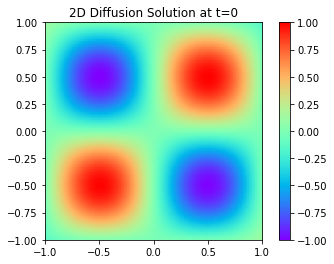

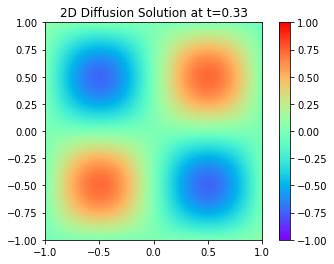

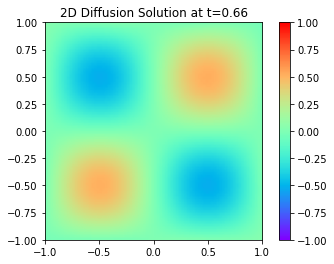

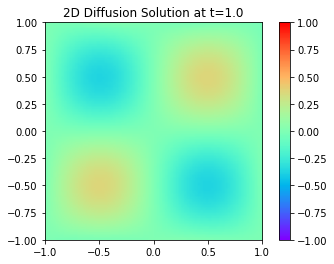

In [9]:
# Visualize the results at different time steps
t_list = [0, 0.33, 0.66, 1.0]
for t in t_list:
    U = evaluate_model(diffusion_model, t)
    cmap='rainbow'
    plt.imshow(U, extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f"2D Diffusion Solution at t={t}")
    plt.show()

Creating 2D comparison animation...
Frame 0/100 - t=0.00
Frame 0/100 - t=0.00
Frame 25/100 - t=0.25
Frame 50/100 - t=0.51
Frame 75/100 - t=0.76
Average error: 0.0069847
Saved 2D comparison video: 2D_Diffusion_2DViz_4L.mp4


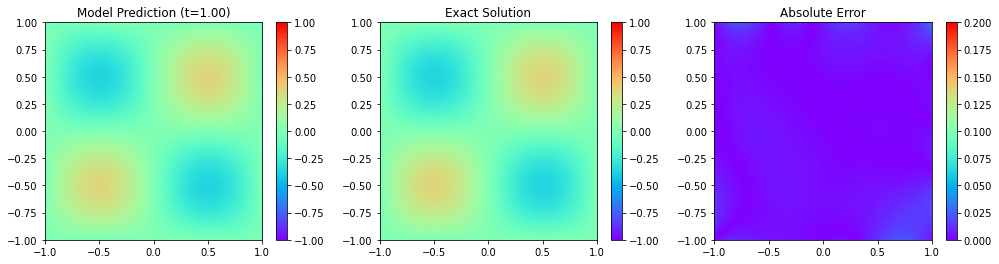

In [10]:
# Create a 2D animation comparing the model prediction to the exact solution over time
def animate_2d_comparison(model, filename, frames=50, N=80, cmap='viridis'):
    print("Creating 2D comparison animation...")

    x = torch.linspace(-1,1,N)
    y = torch.linspace(-1,1,N)

    X, Y = torch.meshgrid(x, y, indexing='ij')

    Xf = X.reshape(-1,1).to(device)
    Yf = Y.reshape(-1,1).to(device)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17,4))

    # Initial images
    im1 = ax1.imshow(np.zeros((N,N)), extent=[-1,1,-1,1],
                     origin='lower', cmap=cmap, vmin=-1, vmax=1)
    im2 = ax2.imshow(np.zeros((N,N)), extent=[-1,1,-1,1],
                     origin='lower', cmap=cmap, vmin=-1, vmax=1)
    im3 = ax3.imshow(np.zeros((N,N)), extent=[-1,1,-1,1],
                     origin='lower', cmap=cmap, vmin=0, vmax=0.2)

    plt.colorbar(im1, ax=ax1)
    plt.colorbar(im2, ax=ax2)
    plt.colorbar(im3, ax=ax3)

    state = {
        "total_error": 0.0
    }

    def update(frame, state):
        t_val = frame / (frames - 1)
        T = torch.full_like(X, t_val)
        Tf = torch.full_like(Xf, t_val).to(device)

        # MLP model prediction
        with torch.no_grad():
            U_pred = model(Xf, Yf, Tf).cpu().numpy().reshape(N,N)

        # Exact solution
        U_exact = exact_solution(X, Y, T).numpy()
        error = np.abs(U_pred - U_exact)
        state["total_error"] += np.mean(error)

        # Update plots
        im1.set_data(U_pred)
        im2.set_data(U_exact)
        im3.set_data(error)

        ax1.set_title(f"Model Prediction (t={t_val:.2f})")
        ax2.set_title("Exact Solution")
        ax3.set_title("Absolute Error")

        if frame % 25 == 0:
            print(f"Frame {frame}/{frames} - t={t_val:.2f}")

    anim = FuncAnimation(fig, functools.partial(update, state=state), frames=frames)

    writer = FFMpegWriter(fps=12)
    anim.save(filename, writer=writer)

    print("Average error:", state["total_error"] / float(frames))

    print("Saved 2D comparison video:", filename)


# Run 2D comparison animation
animate_2d_comparison(diffusion_model, "2D_Diffusion_2DViz_4L.mp4", frames=100, N=256, cmap=cmap)

Creating 3D comparison animation...
Frame 0/100 - t=0.00
Frame 0/100 - t=0.00
Frame 25/100 - t=0.25
Frame 50/100 - t=0.51
Frame 75/100 - t=0.76
Average error: 0.007311489
Saved 3D comparison video: 2D_Diffusion_3DViz_4L.mp4


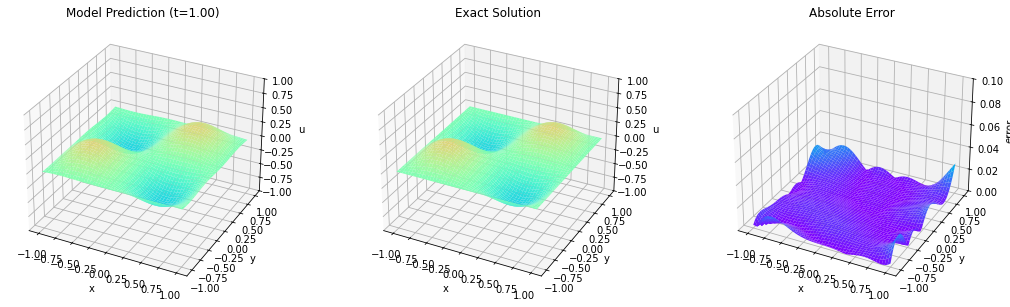

In [11]:
# Create a 3D animation comparing the model prediction to the exact solution over time
def animate_3D_comparison(model, filename, frames=50, N=50, cmap='viridis'):
    print("Creating 3D comparison animation...")

    x = torch.linspace(-1,1,N)
    y = torch.linspace(-1,1,N)

    X, Y = torch.meshgrid(x, y, indexing='ij')

    Xf = X.reshape(-1,1).to(device)
    Yf = Y.reshape(-1,1).to(device)

    fig = plt.figure(figsize=(18,5))
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132, projection='3d')
    ax3 = fig.add_subplot(133, projection='3d')

    state = {
        "total_error": 0.0
    }

    def update(frame, state):
        ax1.clear()
        ax2.clear()
        ax3.clear()
        
        t_val = frame / (frames - 1)
        T = torch.full_like(X, t_val)
        Tf = torch.full_like(Xf, t_val).to(device)

        with torch.no_grad():
            U_pred = model(Xf, Yf, Tf).cpu().numpy().reshape(N,N)

        U_exact = exact_solution(X, Y, T).numpy()
        error = np.abs(U_pred - U_exact)
        state["total_error"] += np.mean(error)

        # Model prediction
        ax1.plot_surface(X.numpy(), Y.numpy(), U_pred, cmap=cmap, edgecolor='none', vmin=-1, vmax=1)
        ax1.set_title(f"Model Prediction (t={t_val:.2f})")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_zlabel("u")
        ax1.set_zlim(-1.0, 1.0)

        # Exact solution
        ax2.plot_surface(X.numpy(), Y.numpy(), U_exact, cmap=cmap, edgecolor='none', vmin=-1, vmax=1)
        ax2.set_title("Exact Solution")
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        ax2.set_zlabel("u")
        ax2.set_zlim(-1.0, 1.0)

        # Absolute error
        max_error = 0.1
        ax3.plot_surface(X.numpy(), Y.numpy(), error, cmap=cmap, edgecolor='none', vmin=0, vmax=max_error)
        ax3.set_title("Absolute Error")
        ax3.set_xlabel("x")
        ax3.set_ylabel("y")
        ax3.set_zlabel("error")
        ax3.set_zlim(0.0, max_error)

        # Rotate both views
        ax1.view_init(elev=30, azim=frame * 3)
        ax2.view_init(elev=30, azim=frame * 3)
        ax3.view_init(elev=30, azim=frame * 3)

        if frame % 25 == 0:
            print(f"Frame {frame}/{frames} - t={t_val:.2f}")

        return []

    anim = FuncAnimation(fig, functools.partial(update, state=state), frames=frames)

    writer = FFMpegWriter(fps=12)
    anim.save(filename, writer=writer)

    print("Average error:", state["total_error"] / float(frames))

    print("Saved 3D comparison video:", filename)


# Run 3D comparison animation
animate_3D_comparison(diffusion_model, "2D_Diffusion_3DViz_4L.mp4", frames=100, cmap=cmap)
